In [14]:
import pandas as pd
import numpy as np
import os

# Take a look at a specific area(Economics)

## Merging datasets and adding known labels

In [15]:
initial_data=pd.read_csv(os.path.join("0_Initial from Internet scimagojr.com", "scimagojr 2023.csv"), sep=";")
cleaned_data=pd.read_csv(os.path.join("CWTS+Datasets", "TOTAL_scimagojr 2023.csv"))

In [16]:
initial_data = initial_data[["Title", "Areas"]]

In [35]:
data_without_labels = pd.merge(cleaned_data, initial_data, on="Title")
data_without_labels

,Title,SJR,H index,IPP,SNIP,Total Docs. (2023),Total Docs. (3years),Total Refs.,Est. value (USD) (2023),Total Cites (3years),Self-Cites/Total Cites (3years),Uncited Docs./Total Docs. (3years),Citable Docs. (3years),Cites / Doc. (2years),Ref. / Doc.,Coverage_Duration,Publisher,Areas
0,Ca-A Cancer Journal for Clinicians,106.094,223,508.896104,167.948451,43,124,3952,1508428.0,35769,0.000699,0.217742,89,385.46,91.91,76,John Wiley and Sons Inc,Medicine
1,Foundations and Trends in Machine Learning,37.044,42,57.923077,24.121591,3,13,897,114748.0,1094,0.000000,0.076923,13,115.11,299.00,17,Now Publishers Inc,Computer Science
2,Nature Reviews Molecular Cell Biology,35.910,531,100.337931,19.301441,115,336,9927,3549661.0,13540,0.003250,0.360119,153,34.40,86.32,26,Nature Research,"Biochemistry, Genetics and Molecular Biology"
3,Quarterly Journal of Economics,30.448,322,15.220588,9.636010,47,136,3645,1383193.0,2166,0.019391,0.036765,136,10.79,77.55,140,Oxford University Press,"Economics, Econometrics and Finance"
4,Nature Reviews Cancer,26.837,527,65.386076,11.500953,105,303,10805,3155228.0,10966,0.005563,0.376238,162,31.34,102.90,25,Nature Publishing Group,"Biochemistry, Genetics and Molecular Biology; ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27107,Zeitschrift der Savigny-Stiftung fur Rechtsges...,0.100,9,0.016129,0.193548,19,64,537,219654.0,4,0.000000,0.937500,64,0.07,28.26,141,Walter de Gruyter GmbH,Arts and Humanities; Social Sciences
27108,Zeitschrift fur Deutsches Altertum und Deutsch...,0.100,6,0.017544,0.242105,29,58,1542,228479.0,4,0.000000,0.948276,57,0.10,53.17,25,Franz Steiner Verlag GmbH,Arts and Humanities; Social Sciences
27109,Zeitschrift fur Kunstgeschichte,0.100,9,0.182446,0.312859,22,68,965,246409.0,5,0.000000,0.926471,66,0.07,43.86,26,Deutscher Kunstverlag GmbH,Arts and Humanities
27110,Zivot Umjetnosti,0.100,3,0.037037,0.181159,18,74,531,234172.0,2,0.000000,0.972973,66,0.00,29.50,17,"Institute of Art History, Zagreb",Arts and Humanities


In [36]:
Labels=pd.read_csv("Labels_2023_all.csv")
data = pd.concat([data_without_labels, Labels], axis=1)
data

,Title,SJR,H index,IPP,SNIP,Total Docs. (2023),Total Docs. (3years),Total Refs.,Est. value (USD) (2023),Total Cites (3years),Self-Cites/Total Cites (3years),Uncited Docs./Total Docs. (3years),Citable Docs. (3years),Cites / Doc. (2years),Ref. / Doc.,Coverage_Duration,Publisher,Areas,Labels
0,Ca-A Cancer Journal for Clinicians,106.094,223,508.896104,167.948451,43,124,3952,1508428.0,35769,0.000699,0.217742,89,385.46,91.91,76,John Wiley and Sons Inc,Medicine,NaN
1,Foundations and Trends in Machine Learning,37.044,42,57.923077,24.121591,3,13,897,114748.0,1094,0.000000,0.076923,13,115.11,299.00,17,Now Publishers Inc,Computer Science,NaN
2,Nature Reviews Molecular Cell Biology,35.910,531,100.337931,19.301441,115,336,9927,3549661.0,13540,0.003250,0.360119,153,34.40,86.32,26,Nature Research,"Biochemistry, Genetics and Molecular Biology",NaN
3,Quarterly Journal of Economics,30.448,322,15.220588,9.636010,47,136,3645,1383193.0,2166,0.019391,0.036765,136,10.79,77.55,140,Oxford University Press,"Economics, Econometrics and Finance",NaN
4,Nature Reviews Cancer,26.837,527,65.386076,11.500953,105,303,10805,3155228.0,10966,0.005563,0.376238,162,31.34,102.90,25,Nature Publishing Group,"Biochemistry, Genetics and Molecular Biology; ...",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27107,Zeitschrift der Savigny-Stiftung fur Rechtsges...,0.100,9,0.016129,0.193548,19,64,537,219654.0,4,0.000000,0.937500,64,0.07,28.26,141,Walter de Gruyter GmbH,Arts and Humanities; Social Sciences,NaN
27108,Zeitschrift fur Deutsches Altertum und Deutsch...,0.100,6,0.017544,0.242105,29,58,1542,228479.0,4,0.000000,0.948276,57,0.10,53.17,25,Franz Steiner Verlag GmbH,Arts and Humanities; Social Sciences,NaN
27109,Zeitschrift fur Kunstgeschichte,0.100,9,0.182446,0.312859,22,68,965,246409.0,5,0.000000,0.926471,66,0.07,43.86,26,Deutscher Kunstverlag GmbH,Arts and Humanities,NaN
27110,Zivot Umjetnosti,0.100,3,0.037037,0.181159,18,74,531,234172.0,2,0.000000,0.972973,66,0.00,29.50,17,"Institute of Art History, Zagreb",Arts and Humanities,NaN


In [73]:
econ_data = data.loc[data['Areas'].str.contains("Economics")] # Mathematics

## Analyse Data

In [74]:
attr=['Title', 'SJR', 'H index', 'IPP', 'SNIP', 'Est. value (USD) (2023)',
       'Self-Cites/Total Cites (3years)', 'Uncited Docs./Total Docs. (3years)',
       'Citable Docs. (3years)', 'Cites / Doc. (2years)', 'Ref. / Doc.',
       'Coverage_Duration']

In [75]:
econ_data.describe()

,SJR,H index,IPP,SNIP,Total Docs. (2023),Total Docs. (3years),Total Refs.,Est. value (USD) (2023),Total Cites (3years),Self-Cites/Total Cites (3years),Uncited Docs./Total Docs. (3years),Citable Docs. (3years),Cites / Doc. (2years),Ref. / Doc.,Coverage_Duration,Labels
count,1224.000000,1224.000000,1224.000000,1224.000000,1224.000000,1224.000000,1224.000000,1.224000e+03,1224.000000,1224.000000,1224.000000,1224.000000,1224.000000,1224.000000,1224.000000,382.000000
mean,0.888516,40.920752,2.218238,0.986281,53.147876,142.563725,2789.879902,7.028364e+05,472.986928,0.090686,0.453392,137.432190,1.987680,50.548873,23.381536,0.753927
std,1.975415,46.459799,2.464819,0.891780,96.332036,213.070280,5224.613451,1.160249e+06,1435.546623,0.109507,0.232075,202.946844,2.163536,22.854226,17.360655,0.431287
min,0.101000,2.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2.601000e+03,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,3.000000,0.000000
25%,0.201750,12.750000,0.606103,0.420296,18.000000,57.000000,753.750000,2.139242e+05,41.000000,0.023599,0.272727,54.000000,0.587500,38.507500,11.000000,1.000000
50%,0.376500,25.000000,1.413462,0.790569,31.000000,88.000000,1441.000000,3.946670e+05,118.000000,0.058323,0.440238,84.000000,1.290000,49.445000,18.000000,1.000000
75%,0.798000,52.000000,2.859424,1.260360,51.000000,141.000000,2792.250000,6.999288e+05,348.000000,0.111111,0.633571,136.250000,2.532500,61.190000,31.250000,1.000000
max,30.448000,380.000000,18.820809,9.636010,1437.000000,3024.000000,74352.000000,1.420234e+07,23439.000000,0.906667,0.982143,2905.000000,17.020000,223.830000,171.000000,1.000000


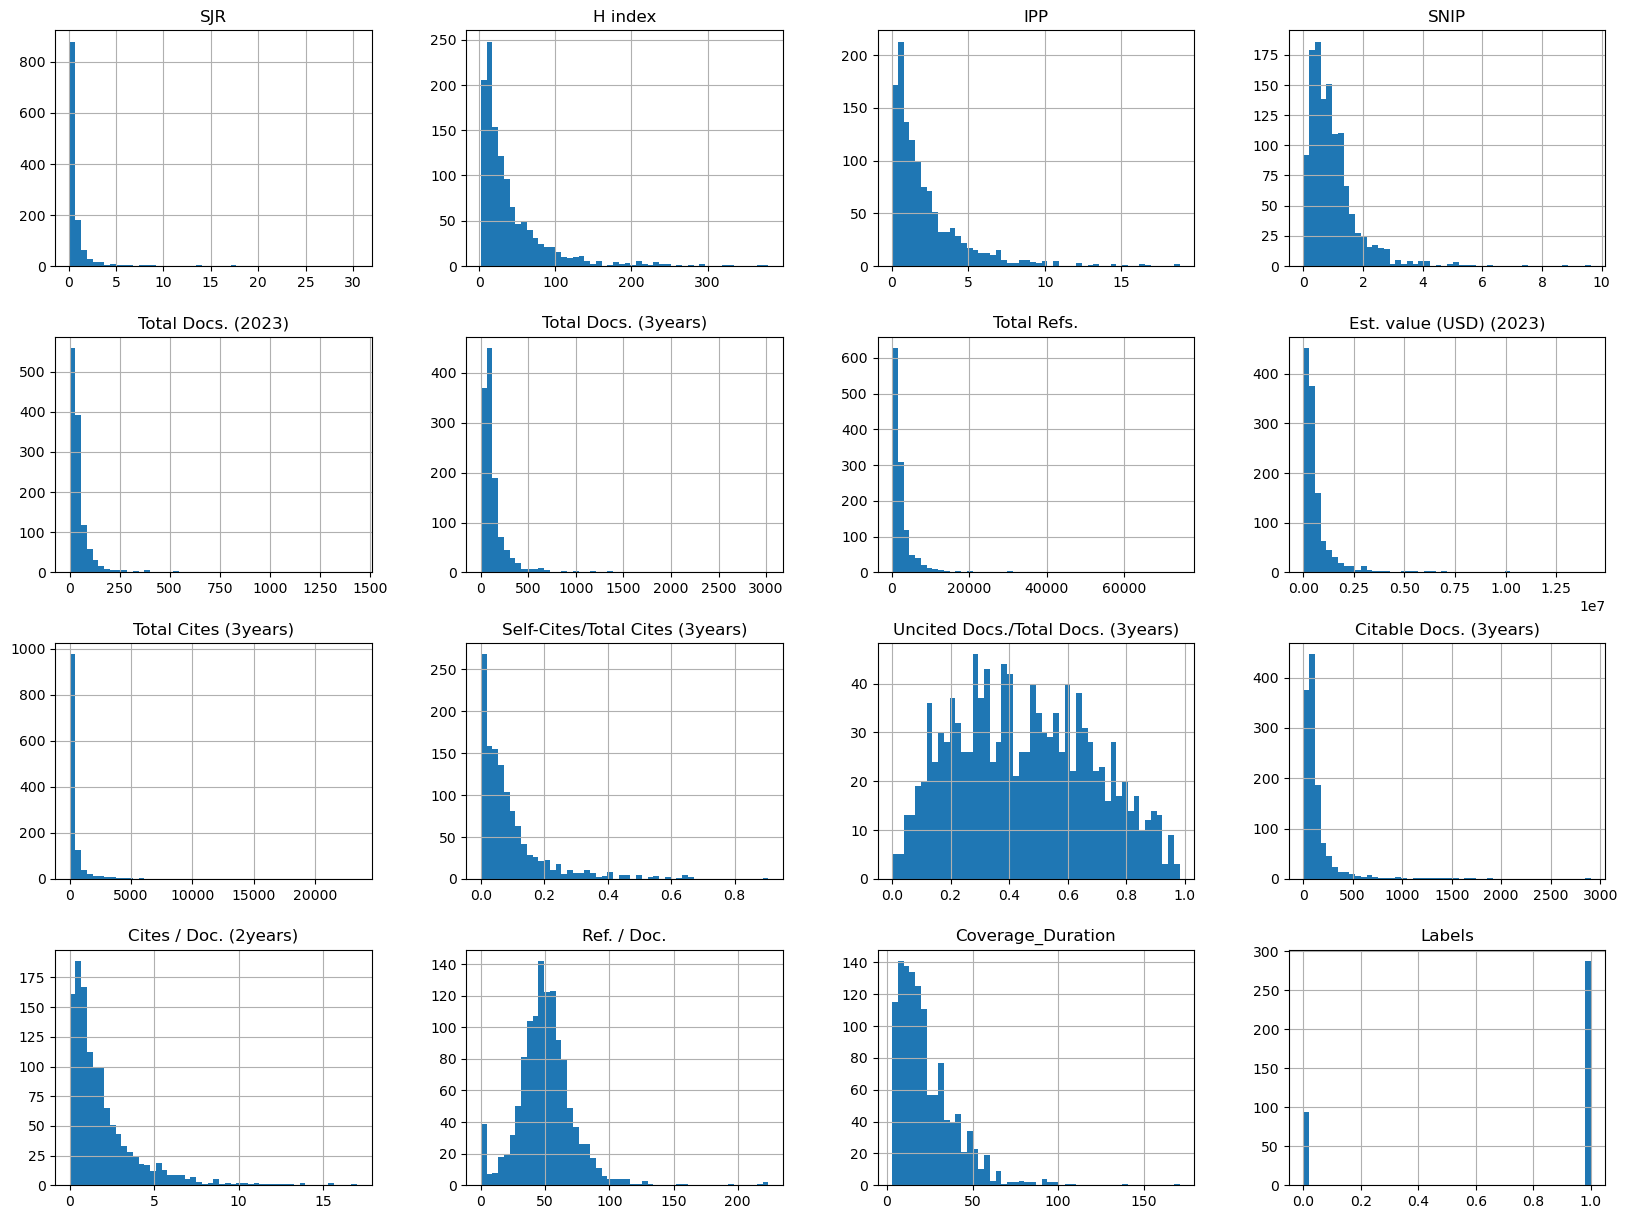

In [76]:
%matplotlib inline
import matplotlib.pyplot as plt
econ_data.hist(bins=50, figsize=(20,15))
plt.show()

array([[<Axes: xlabel='SJR', ylabel='SJR'>,
        <Axes: xlabel='H index', ylabel='SJR'>,
        <Axes: xlabel='IPP', ylabel='SJR'>,
        <Axes: xlabel='SNIP', ylabel='SJR'>,
        <Axes: xlabel='Est. value (USD) (2023)', ylabel='SJR'>,
        <Axes: xlabel='Self-Cites/Total Cites (3years)', ylabel='SJR'>,
        <Axes: xlabel='Uncited Docs./Total Docs. (3years)', ylabel='SJR'>,
        <Axes: xlabel='Citable Docs. (3years)', ylabel='SJR'>,
        <Axes: xlabel='Cites / Doc. (2years)', ylabel='SJR'>,
        <Axes: xlabel='Ref. / Doc.', ylabel='SJR'>,
        <Axes: xlabel='Coverage_Duration', ylabel='SJR'>],
       [<Axes: xlabel='SJR', ylabel='H index'>,
        <Axes: xlabel='H index', ylabel='H index'>,
        <Axes: xlabel='IPP', ylabel='H index'>,
        <Axes: xlabel='SNIP', ylabel='H index'>,
        <Axes: xlabel='Est. value (USD) (2023)', ylabel='H index'>,
        <Axes: xlabel='Self-Cites/Total Cites (3years)', ylabel='H index'>,
        <Axes: xlabel='Uncited 

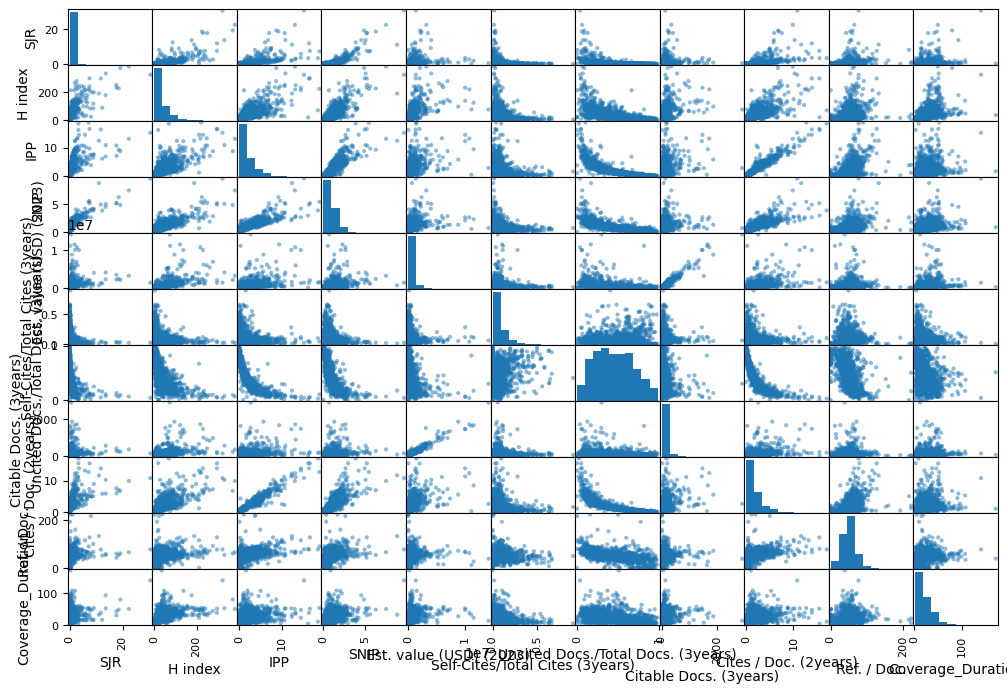

In [77]:
from pandas.plotting import scatter_matrix

attributes=['SJR', 'H index', 'IPP', 'SNIP', 'Est. value (USD) (2023)',
       'Self-Cites/Total Cites (3years)', 'Uncited Docs./Total Docs. (3years)',
       'Citable Docs. (3years)', 'Cites / Doc. (2years)', 'Ref. / Doc.',
       'Coverage_Duration']
scatter_matrix(econ_data[attributes], figsize=(12, 8))

In [78]:
corr_matrix = econ_data[attributes + ["Labels"]].corr()
corr_matrix["Labels"].sort_values(ascending=False)

Labels                                1.000000
SNIP                                  0.454817
IPP                                   0.397965
Cites / Doc. (2years)                 0.392762
H index                               0.359461
Ref. / Doc.                           0.299412
SJR                                   0.285798
Coverage_Duration                     0.231124
Est. value (USD) (2023)               0.200947
Citable Docs. (3years)                0.156868
Self-Cites/Total Cites (3years)      -0.055571
Uncited Docs./Total Docs. (3years)   -0.614536
Name: Labels, dtype: float64

## Train Model

In [92]:
train= econ_data.drop(columns=["Title","Publisher", "Total Docs. (2023)","Total Docs. (3years)", "Total Refs.", "Total Cites (3years)", "Citable Docs. (3years)", "Areas", "Labels"])
labeled_X= train[~econ_data["Labels"].isna()]
labeled_X

,SJR,H index,IPP,SNIP,Est. value (USD) (2023),Self-Cites/Total Cites (3years),Uncited Docs./Total Docs. (3years),Cites / Doc. (2years),Ref. / Doc.,Coverage_Duration
38,13.655,331,10.872987,5.047825,4116469.0,0.018767,0.071048,10.23,54.57,52
82,9.161,198,7.567329,4.205613,4028610.0,0.069051,0.246696,8.91,46.95,53
102,8.337,197,7.400000,4.115340,1086890.0,0.047191,0.072993,4.86,59.90,47
142,7.194,221,18.820809,5.443238,1484139.0,0.038556,0.100529,12.72,89.93,53
160,6.564,158,4.599388,2.716527,2210016.0,0.034317,0.218845,3.95,39.57,51
...,...,...,...,...,...,...,...,...,...,...
26232,0.102,6,0.017391,0.005405,460277.0,0.000000,0.982143,0.03,13.67,23
26343,0.102,8,0.068182,0.102557,247523.0,0.454545,0.875000,0.14,50.31,24
26388,0.101,8,0.107143,0.940809,233299.0,0.333333,0.890625,0.18,30.88,17
26692,0.101,2,0.043478,0.042271,320471.0,0.500000,0.925170,0.10,19.53,8


In [93]:
import math

cleaned_y = [x for x in econ_data["Labels"] if not (isinstance(x, float) and math.isnan(x))]
len(cleaned_y)

382

In [110]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(train) #use it on All DATA


X_train, X_test, y_train, y_test=train_test_split(labeled_X, cleaned_y, test_size=0.25)

In [111]:
from sklearn.linear_model import LogisticRegression

X_train=scaler.transform(X_train)
X_test=scaler.transform(X_test)
log_reg = LogisticRegression(solver="lbfgs", random_state=42)
log_reg.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [112]:
y_pred=log_reg.predict(X_test)

In [113]:
log_reg.score(X_train,y_train)

0.8601398601398601

### Evaluate the MODEL

In [114]:
from sklearn.model_selection import cross_val_score

log_score = cross_val_score(log_reg, X_train, y_train,
                              scoring="accuracy", cv=3)
log_score

array([0.85416667, 0.86315789, 0.81052632])

In [115]:
from sklearn.metrics import confusion_matrix

y_pred=log_reg.predict(X_test)
confusion_matrix(y_test, y_pred)

array([[19,  8],
       [ 2, 67]], dtype=int64)

In [119]:
from sklearn.model_selection import cross_val_predict

y_scores = cross_val_predict(log_reg, X_train, y_train, cv=3,
                             method="decision_function")

from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train, y_scores)

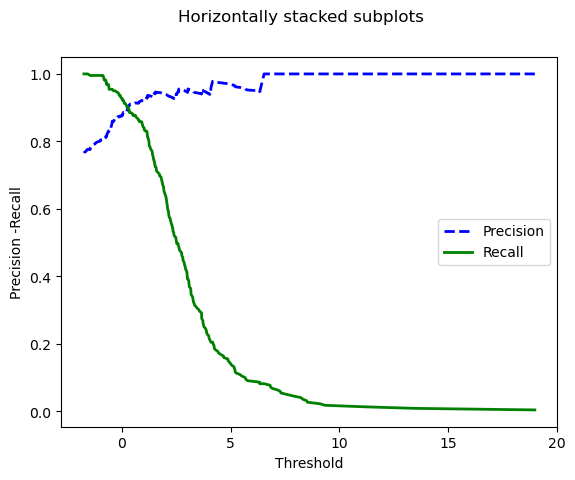

In [120]:
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
#threshold=10
fig, ax1 = plt.subplots(1, 1)
fig.suptitle('Horizontally stacked subplots')


ax1.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
ax1.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
#ax3.plot(precisions[:-1], recalls[:-1], "g-", label="Recall", linewidth=2)

#plt.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")
#ax.plot3D(x, y, z, 'green')
# extra code – this section just beautifies and saves Figure 3–5
#idx = (thresholds >= threshold).argmax()  # first index ≥ threshold
#plt.plot(thresholds[idx], precisions[idx], "bo")
#plt.plot(thresholds[idx], recalls[idx], "go")
#plt.axis([-50000, 50000, 0, 1])

ax1.set_xlabel('Threshold')
ax1.set_ylabel('Precision -Recall')
#ax2.set_xlabel('Threshold')
#ax2.set_ylabel('Recall')
#ax3.set_xlabel('Precision')
#ax3.set_ylabel('Recall')

ax1.legend(loc="center right")
#save_fig("precision_recall_vs_threshold_plot")
#plt.show()

In [122]:
idx_for_90_precision = (precisions >= 0.90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]

In [124]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train, y_scores)

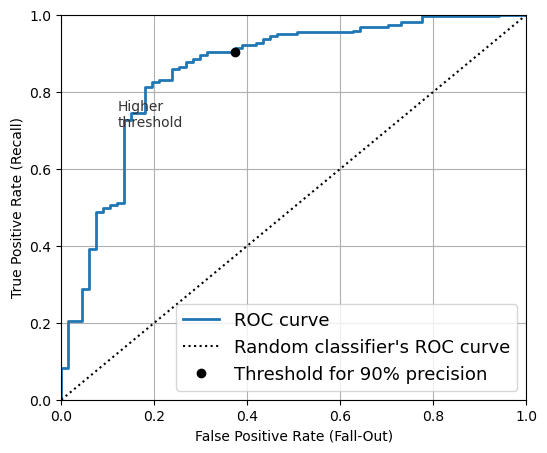

In [125]:
idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

plt.figure(figsize=(6, 5))  # extra code – not needed, just formatting
plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.plot([fpr_90], [tpr_90], "ko", label="Threshold for 90% precision")

# extra code – just beautifies and saves Figure 3–7

plt.text(0.12, 0.71, "Higher\nthreshold", color="#333333")
plt.xlabel('False Positive Rate (Fall-Out)')
plt.ylabel('True Positive Rate (Recall)')
plt.grid()
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower right", fontsize=13)
#save_fig("roc_curve_plot")

plt.show()


In [126]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train, y_scores)

0.8568799836434267

### Feature Importance

<Axes: ylabel='Feature'>

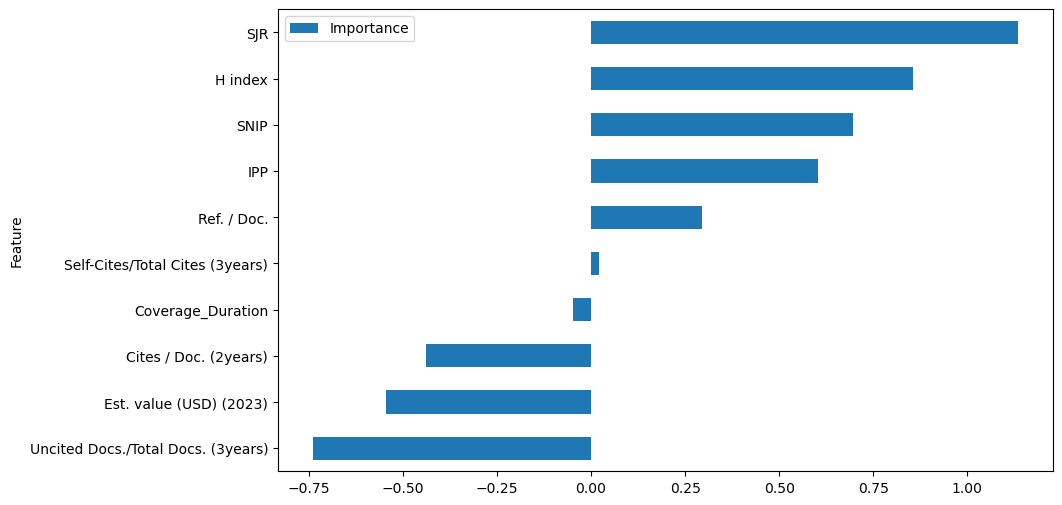

In [128]:
feature_importance = pd.DataFrame({'Feature': labeled_X.columns, 'Importance': log_reg.coef_[0]})
feature_importance = feature_importance.sort_values('Importance', ascending=True)
feature_importance.plot(x='Feature', y='Importance', kind='barh', figsize=(10, 6))